In [1]:
import pandas as pd
import networkx as nx

df = pd.read_csv("../data/delivery_data.csv")

df["delay_ratio"] = (
    df["actual_time"] /
    df["osrm_time"]
)

corridor_df = (
    df.groupby(
        ["source_center", "destination_center"]
    )["delay_ratio"]
    .median()
    .reset_index()
)

G = nx.from_pandas_edgelist(
    corridor_df,
    source="source_center",
    target="destination_center",
    edge_attr="delay_ratio",
    create_using=nx.DiGraph()
)

In [2]:
betweenness = nx.betweenness_centrality(G)

In [3]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

In [4]:
clustering = nx.clustering(
    G.to_undirected()
)

In [5]:
hub_df = pd.DataFrame({
    "hub": list(betweenness.keys()),
    "betweenness": list(betweenness.values()),
    "in_degree": [
        in_degree[node]
        for node in betweenness.keys()
    ],
    "out_degree": [
        out_degree[node]
        for node in betweenness.keys()
    ],
    "clustering": [
        clustering[node]
        for node in betweenness.keys()
    ]
})

In [6]:
top_bottlenecks = hub_df.sort_values(
    "betweenness",
    ascending=False
)

top_bottlenecks.head(10)

,hub,betweenness,in_degree,out_degree,clustering
25,IND000000ACB,0.220228,45,49,0.037158
12,IND562132AAA,0.124943,36,35,0.053571
64,IND501359AAE,0.092632,30,27,0.042683
67,IND712311AAA,0.090659,24,22,0.039216
61,IND421302AAG,0.069625,29,29,0.061562
24,IND160002AAC,0.055078,32,29,0.034330
47,IND131028AAB,0.047837,20,20,0.038710
110,IND781018AAB,0.044542,17,15,0.031621
1,IND411033AAA,0.043254,23,20,0.061576
66,IND600056AAB,0.042146,18,18,0.059289


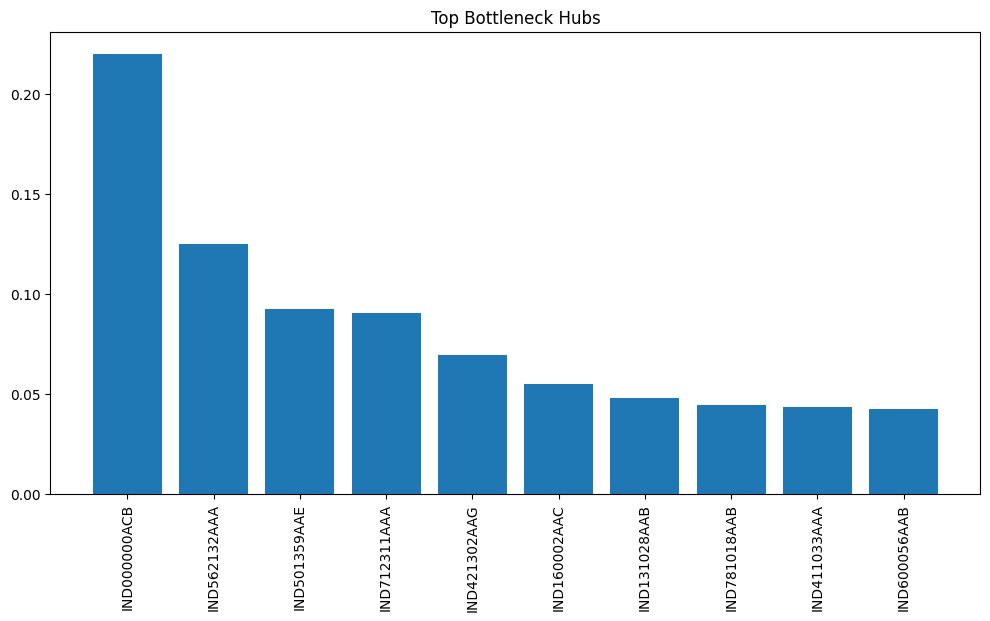

In [7]:
import matplotlib.pyplot as plt

top10 = top_bottlenecks.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["hub"],
    top10["betweenness"]
)

plt.xticks(rotation=90)

plt.title("Top Bottleneck Hubs")

plt.show()

In [8]:
top_corridors = corridor_df.sort_values(
    "delay_ratio",
    ascending=False
)

top_corridors.head(10)

,source_center,destination_center,delay_ratio
488,IND212402AAA,IND211002AAB,31.787879
2555,IND785634AAA,IND785001AAA,31.200000
455,IND208012AAA,IND209304AAA,27.200000
1139,IND416606AAA,IND416510AAA,26.880918
2710,IND842003AAB,IND482002AAA,23.187500
1208,IND424304AAC,IND424006AAA,22.313663
1213,IND425405AAA,IND424006AAA,21.185587
2347,IND722140AAA,IND723130AAA,19.130435
148,IND121002AAA,IND121004AAB,19.083333
498,IND221313AAA,IND221401AAA,16.714286


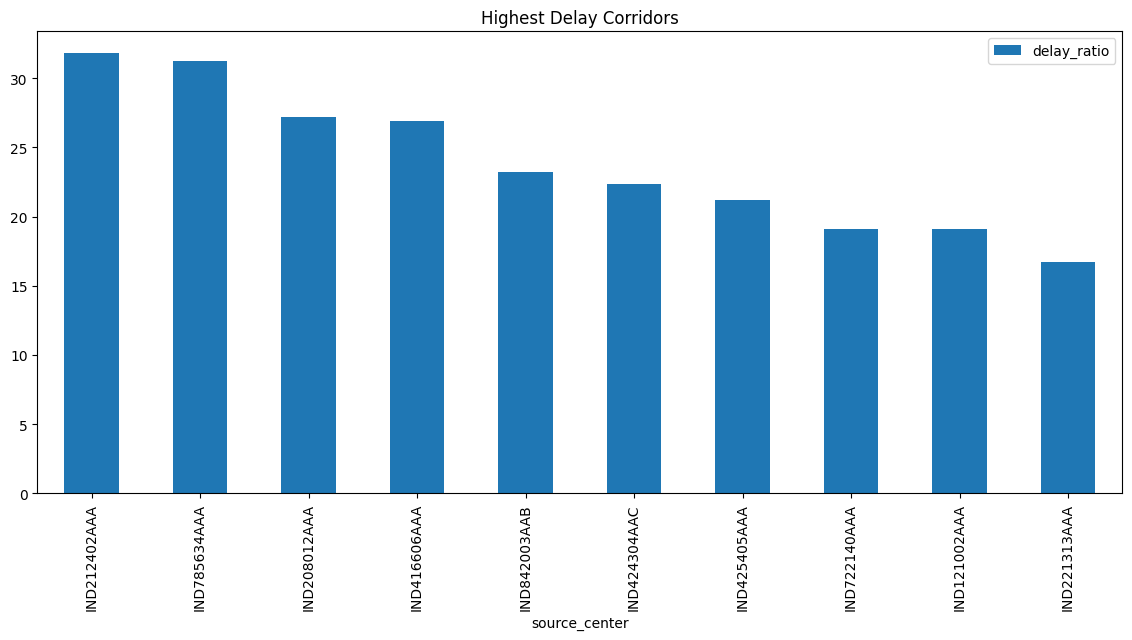

In [9]:
top_corridors.head(10).plot(
    x="source_center",
    y="delay_ratio",
    kind="bar",
    figsize=(14,6)
)

plt.title("Highest Delay Corridors")
plt.show()